<a href="https://colab.research.google.com/github/fernandouribeu/analisis_datos/blob/main/Laboratorio_04_Series_Temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Práctico 4 · Análisis y preparación de series temporales

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Código:** MDSC3S112-1  

**Estudiante:** _Fernando Uribe_  
**Fecha:** _08-09-2026_

---

### Objetivo

Pasar desde un conjunto de datos que contiene una fecha a una serie temporal correctamente organizada, diagnosticada y preparada para un posterior proceso de modelamiento.

> **Importante:** En este laboratorio no se requiere construir modelos ARIMA ni realizar forecasting.


## 1. Contexto del problema

En este laboratorio se analizarán datos mensuales de una organización.

El objetivo es comprender cómo evoluciona la variable `ventas_clp` a través del tiempo y determinar si los datos están correctamente preparados para un posterior análisis de series temporales.

### Preguntas orientadoras

- ¿Cuál es la variable principal que se desea analizar?
- ¿Cuál es la dimensión temporal?
- ¿Por qué puede ser relevante estudiar las ventas a través del tiempo?
- ¿Qué decisiones empresariales podrían beneficiarse de este análisis?

### Interpretación

Escriba aquí una breve descripción del problema analítico.


### Preguntas orientadoras

* **¿Cuál es la variable principal que se desea analizar?:** La variable objetivo es `ventas_clp`, que representa los ingresos mensuales en pesos chilenos.
* **¿Cuál es la dimensión temporal?:** La variable `fecha`, que indica el inicio de cada periodo mensual registrado.
* **¿Por qué resulta relevante estudiar las ventas a través del tiempo?:** Permite entender la trayectoria real del negocio, aislar subidas o caídas estacionales y tomar decisiones basadas en patrones continuos y no en eventos aislados.
* **¿Qué decisiones empresariales podrían beneficiarse de este análisis?:** La planificación del presupuesto anual, la asignación de metas comerciales, el control de inventarios y la optimización del gasto publicitario previo a los meses de mayor demanda.

### Interpretación

El objetivo analítico es diagnosticar la estructura, calidad y comportamiento histórico de la facturación mensual para dejar la información limpia y ordenada antes de construir cualquier modelo de proyecciones.

## 2. Carga del dataset

Cargue el dataset y realice una primera inspección de sus características.

Revise:

- dimensiones;
- primeras observaciones;
- nombres de variables;
- tipos de datos;
- valores faltantes;
- estadísticas descriptivas.


In [20]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf


# Carga del dataset
# Carga de la carpeta a drive
from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Analisis de Datos/Laboratorio4/ventas_mensuales.csv")


# Complete aquí la exploración inicial
print("--- DIMENSIONES DEL DATASET ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- PRIMERAS OBSERVACIONES ---")
print(df.head())

print("\n--- INFORMACIÓN DE TIPOS DE DATOS ---")
print(df.dtypes)

print("\n--- VALORES FALTANTES ---")
print(df.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- DIMENSIONES DEL DATASET ---
Filas: 73, Columnas: 6

--- PRIMERAS OBSERVACIONES ---
        fecha  ventas_clp  clientes_activos  inversion_marketing_clp  \
0  2022-12-01  70822132.0              2146                2181424.0   
1  2024-06-01  71615984.0              2521                3244282.0   
2  2024-12-01  80983706.0              2626                2162341.0   
3  2024-05-01  67912327.0              2405                3211852.0   
4  2024-04-01  67344214.0              2416                2947667.0   

   precio_promedio  promocion  
0            31825          1  
1            31809          1  
2            32682          0  
3            31220          1  
4            31784          1  

--- INFORMACIÓN DE TIPOS DE DATOS ---
fecha                       object
ventas_clp                 float64
clientes_activos             int64
inversion_marke

### Preguntas orientadoras

- ¿Cuántas observaciones existen?
- ¿Qué variables contiene el dataset?
- ¿La variable temporal está almacenada con el tipo de dato adecuado?
- ¿Existen valores faltantes?

### Interpretación

Describa brevemente la estructura inicial de los datos e identifique posibles problemas.


### Preguntas orientadoras

* **¿Cuántas observaciones existen?:** Existen 73 observaciones (filas) en la carga inicial del archivo.
* **¿Qué variables contiene el dataset?:** Contiene 6 variables (`fecha`, `ventas_clp`, `clientes_activos`, `inversion_marketing_clp`, `precio_promedio` y `promocion`).
* **¿La variable temporal está almacenada con el tipo de dato adecuado?:** No, ingresa como texto simple (`object`) y requiere ser convertida a formato de fecha (`datetime`).
* **¿Existen valores faltantes?:** Sí, se identifican 2 datos faltantes en total: 1 en `ventas_clp` y 1 en `inversion_marketing_clp`.

### Interpretación

* **Estructura general:** La base cuenta con 73 observaciones iniciales y 6 variables que combinan facturación, clientes e inversión comercial.
* **Formato temporal:** La variable `fecha` viene guardada como texto, por lo que se debe transformar a tipo fecha para poder medir el paso del tiempo.
* **Calidad de información:** Hay 2 casilleros vacíos que requieren corrección antes de trabajar la serie de tiempo.
* **Rango de ingresos:** La facturación mensual promedio alcanza los 58.262.554 CLP, moviéndose entre un piso de 37.947.147 CLP y un techo de 87.383.524 CLP.

## 3. Identificación de la variable temporal

Identifique la variable que representa el tiempo y conviértala al tipo de dato apropiado.

Determine:

- fecha mínima;
- fecha máxima;
- tipo de dato;
- cantidad de observaciones;
- existencia de fechas duplicadas.


In [2]:
# Conversión de la variable temporal

# df["fecha"] = pd.to_datetime(df["fecha"])

# Complete el análisis
df["fecha"] = pd.to_datetime(df["fecha"])

fecha_min = df["fecha"].min()
fecha_max = df["fecha"].max()
tipo_dato = df["fecha"].dtype
total_obs = len(df)
fechas_duplicadas = df["fecha"].duplicated().sum()

print("--- DIAGNÓSTICO DE LA VARIABLE TEMPORAL ---")
print(f"Tipo de dato: {tipo_dato}")
print(f"Fecha mínima (inicio): {fecha_min.strftime('%Y-%m-%d')}")
print(f"Fecha máxima (cierre): {fecha_max.strftime('%Y-%m-%d')}")
print(f"Total de registros: {total_obs}")
print(f"Cantidad de fechas duplicadas: {fechas_duplicadas}")

--- DIAGNÓSTICO DE LA VARIABLE TEMPORAL ---
Tipo de dato: datetime64[ns]
Fecha mínima (inicio): 2020-01-01
Fecha máxima (cierre): 2025-12-01
Total de registros: 73
Cantidad de fechas duplicadas: 1


### Preguntas orientadoras

- ¿Cuál es la variable temporal?
- ¿Está correctamente representada?
- ¿Cada fecha representa una única observación?
- ¿Existen fechas duplicadas?
- ¿Qué período temporal cubren los datos?

### Interpretación

Justifique por qué la variable seleccionada puede utilizarse como dimensión temporal.


### Preguntas orientadoras

* **¿Cuál es la variable temporal?:** La columna `fecha`.
* **¿Está correctamente representada?:** Sí, tras transformarla mediante `pd.to_datetime()`, queda guardada como `datetime64[ns]`.
* **¿Cada fecha representa una única observación?:** No en el archivo original, ya que hay 73 filas pero solo 72 fechas únicas.
* **¿Existen fechas duplicadas?:** Sí, se registra 1 fecha duplicada en la base.
* **¿Qué período temporal cubren los datos?:** Cubren un lapso de 6 años completos, desde el 01-01-2020 hasta el 01-12-2025.

### Interpretación

La columna `fecha` es la dimensión temporal adecuada porque marca la secuencia cronológica mes a mes. Al convertirla a formato de fecha, se puede organizar el historial en orden correcto y detectar la presencia de 1 registro duplicado que debe eliminarse para evitar contar dos veces el mismo período.

## 4. Revisión de frecuencia y orden temporal

Ordene las observaciones cronológicamente y establezca la variable temporal como índice.

Analice la distancia entre observaciones consecutivas y determine la frecuencia efectiva de los datos.


In [6]:
# Orden cronológico

# df = df.sort_values("fecha").copy()

# Establecer índice temporal

# df = df.set_index("fecha")

# Complete el análisis de frecuencia

# Asegurar orden temporal
df = df.sort_values(by=df.index.name if df.index.name == 'fecha' else 'fecha')

# Eliminar duplicados si 'fecha' ya es índice o si sigue siendo columna
if 'fecha' in df.columns:
    df_clean = df.drop_duplicates(subset=['fecha']).copy()
    df_clean['fecha'] = pd.to_datetime(df_clean['fecha'])
    df_clean = df_clean.set_index('fecha')
else:
    df_clean = df[~df.index.duplicated(keep='first')].copy()

# Ordenar índice
df_clean = df_clean.sort_index()

# Analizar la distancia entre observaciones consecutivas
diferencia_dias = df_clean.index.to_series().diff()

print("--- ANÁLISIS DE FRECUENCIA TEMPORAL ---")
print("Recuento del intervalo de días entre observaciones:")
print(diferencia_dias.value_counts())

print(f"\nCantidad de registros tras remover duplicados: {len(df_clean)}")
print(f"Frecuencia automática detectada: {pd.infer_freq(df_clean.index)}")

# Asignar formalmente la frecuencia mensual al inicio de cada mes ('MS')
df_clean = df_clean.asfreq('MS')
print(f"¿Existen huecos vacíos tras fijar frecuencia?: {df_clean['ventas_clp'].isnull().sum()}")

--- ANÁLISIS DE FRECUENCIA TEMPORAL ---
Recuento del intervalo de días entre observaciones:
fecha
31 days    41
30 days    24
28 days     4
29 days     2
Name: count, dtype: int64

Cantidad de registros tras remover duplicados: 72
Frecuencia automática detectada: MS
¿Existen huecos vacíos tras fijar frecuencia?: 1


### Preguntas orientadoras

- ¿Las observaciones están ordenadas cronológicamente?
- ¿Cuál es la frecuencia de observación?
- ¿La frecuencia es regular?
- ¿Existen períodos sin observaciones?
- ¿La frecuencia observada coincide con la esperada?

### Interpretación

Determine la frecuencia temporal de la serie y explique si existen problemas de regularidad.


### Preguntas orientadoras

* **¿Las observaciones están ordenadas cronológicamente?:** Sí, al ordenar la base por la columna fecha y fijarla como índice principal.
* **¿Cuál es la frecuencia de observación?:** Frecuencia mensual regular, fijada al inicio de cada mes (`MS`).
* **¿La frecuencia es regular?:** Sí, las variaciones de 28, 29, 30 y 31 días corresponden a la duración normal de los meses en el calendario.
* **¿Existen períodos sin observaciones?:** No, no existen meses faltantes entre el 2020 y el 2025 tras eliminar la fila duplicada.
* **¿La frecuencia observada coincide con la esperada?:** Sí, coincide con el registro operativo mensual del negocio.

### Interpretación

Una vez removida la observación repetida, la serie queda compuesta por 72 meses continuos y perfectamente ordenados en el tiempo. La frecuencia es regular y mensual, abarcando desde el **01-01-2020 hasta el 01-12-2025** sin huecos temporales en la secuencia.

## 5. Calidad y consistencia de la serie

Realice un diagnóstico de calidad específico para datos temporales.

Revise:

- valores faltantes;
- fechas duplicadas;
- orden temporal;
- continuidad;
- valores potencialmente problemáticos en la variable objetivo.

Si detecta un problema, documente la decisión tomada para abordarlo.


In [13]:
# Valores faltantes

# Complete el análisis


# Fechas duplicadas

# Complete el análisis


# Continuidad temporal

# Complete el análisis


# Valores potencialmente problemáticos

# Complete el análisis


# Descubrir qué fechas contienen valores faltantes (NaN)
nulos_ventas_fechas = df_clean[df_clean['ventas_clp'].isnull()].index
nulos_mkt_fechas = df_clean[df_clean['inversion_marketing_clp'].isnull()].index

print("--- PASO 1: DETECCIÓN AUTOMÁTICA DE REGISTROS FALTANTES ---")
print("Fechas con datos vacíos en 'ventas_clp':", [f.strftime('%Y-%m-%d') for f in nulos_ventas_fechas])
print("Fechas con datos vacíos en 'inversion_marketing_clp':", [f.strftime('%Y-%m-%d') for f in nulos_mkt_fechas])

# Mostrar los valores del mes anterior y posterior para entender el origen de la interpolación
print("\n--- PASO 2: VALORES DE LOS MESES VECINOS PARA LA INTERPOLACIÓN ---")

for f in nulos_ventas_fechas:
    idx = df_clean.index.get_loc(f)
    f_ant, f_pos = df_clean.index[idx - 1], df_clean.index[idx + 1]
    v_ant, v_pos = df_clean.loc[f_ant, 'ventas_clp'], df_clean.loc[f_pos, 'ventas_clp']
    print(f"Variable: ventas_clp | Fecha vacía: {f.strftime('%Y-%m-%d')}")
    print(f"  -> Mes anterior ({f_ant.strftime('%Y-%m-%d')}): {v_ant:,.0f} CLP")
    print(f"  -> Mes posterior ({f_pos.strftime('%Y-%m-%d')}): {v_pos:,.0f} CLP")

for f in nulos_mkt_fechas:
    idx = df_clean.index.get_loc(f)
    f_ant, f_pos = df_clean.index[idx - 1], df_clean.index[idx + 1]
    v_ant, v_pos = df_clean.loc[f_ant, 'inversion_marketing_clp'], df_clean.loc[f_pos, 'inversion_marketing_clp']
    print(f"Variable: inversion_marketing_clp | Fecha vacía: {f.strftime('%Y-%m-%d')}")
    print(f"  -> Mes anterior ({f_ant.strftime('%Y-%m-%d')}): {v_ant:,.0f} CLP")
    print(f"  -> Mes posterior ({f_pos.strftime('%Y-%m-%d')}): {v_pos:,.0f} CLP")

# Ejecutar la interpolación lineal sobre la serie
df_clean['ventas_clp_imp'] = df_clean['ventas_clp'].interpolate(method='linear')
df_clean['inversion_marketing_clp_imp'] = df_clean['inversion_marketing_clp'].interpolate(method='linear')

# Imprimir los resultados obtenidos
print("\n--- PASO 3: VALORES IMPUTADOS OBTENIDOS ---")
for f in nulos_ventas_fechas:
    v_imp = df_clean.loc[f, 'ventas_clp_imp']
    print(f"Ventas imputadas para {f.strftime('%Y-%m-%d')}: {v_imp:,.1f} CLP")

for f in nulos_mkt_fechas:
    v_imp = df_clean.loc[f, 'inversion_marketing_clp_imp']
    print(f"Marketing imputado para {f.strftime('%Y-%m-%d')}: {v_imp:,.1f} CLP")

print(f"\nNulos restantes en la serie de ventas: {df_clean['ventas_clp_imp'].isnull().sum()}")
print(f"Cantidad de ventas menores o iguales a cero: {(df_clean['ventas_clp_imp'] <= 0).sum()}")

--- PASO 1: DETECCIÓN AUTOMÁTICA DE REGISTROS FALTANTES ---
Fechas con datos vacíos en 'ventas_clp': ['2024-01-01']
Fechas con datos vacíos en 'inversion_marketing_clp': ['2022-02-01']

--- PASO 2: VALORES DE LOS MESES VECINOS PARA LA INTERPOLACIÓN ---
Variable: ventas_clp | Fecha vacía: 2024-01-01
  -> Mes anterior (2023-12-01): 78,080,889 CLP
  -> Mes posterior (2024-02-01): 50,003,552 CLP
Variable: inversion_marketing_clp | Fecha vacía: 2022-02-01
  -> Mes anterior (2022-01-01): 2,553,302 CLP
  -> Mes posterior (2022-03-01): 3,107,138 CLP

--- PASO 3: VALORES IMPUTADOS OBTENIDOS ---
Ventas imputadas para 2024-01-01: 64,042,220.5 CLP
Marketing imputado para 2022-02-01: 2,830,220.0 CLP

Nulos restantes en la serie de ventas: 0
Cantidad de ventas menores o iguales a cero: 0


### Preguntas orientadoras

- ¿Existen fechas faltantes?
- ¿Existen observaciones duplicadas?
- ¿Existen valores faltantes en la variable objetivo?
- ¿Existen valores que parezcan imposibles o sospechosos?
- ¿Qué consecuencias tendría mantener estos problemas antes del modelamiento?

### Interpretación

Explique qué problemas encontró y cómo decidió abordarlos.

Toda modificación debe estar justificada.


### Preguntas orientadoras

* **¿Existen fechas faltantes?:** No, la secuencia temporal cubre los 72 meses continuos sin saltos.
* **¿Existen observaciones duplicadas?:** Sí, se identificó 1 duplicado en el índice y se removió en el paso anterior.
* **¿Existen valores faltantes en la variable objetivo?:** Sí, 1 valor faltante en `ventas_clp` en enero de 2024, el cual se estimó en 64.042.220,5 CLP mediante interpolación lineal.
* **¿Existen valores que parezcan imposibles o sospechosos?:** No, existen 0 registros con ventas menores o iguales a cero.
* **¿Qué consecuencias tendría mantener estos problemas antes del modelamiento?:** Mantener huecos vacíos o fechas repetidas quiebra el cálculo de los desfases de tiempo y produce errores en cualquier modelo predictivo.

### Interpretación

Se eliminó el registro repetido de fecha y se completaron mediante interpolación lineal los 2 vacíos de la base (estimando 64.042.220,5 CLP para las ventas de enero de 2024 y 2.830.220 CLP para el gasto en marketing de febrero de 2022). Se eligió la interpolación sobre el borrado para mantener la secuencia continua de 72 meses sin perder información del entorno.

## 6. Exploración temporal

Construya una visualización de la variable `ventas_clp` a través del tiempo.

La visualización debe permitir observar claramente la evolución de las ventas.


Fecha primera observación: 2020-01-01
Ventas primera observación: 37947147.0
Fecha última observación: 2025-12-01
Ventas última observación: 87383524.0
Venta mínima de la serie: 37947147.0
Venta máxima de la serie: 87383524.0


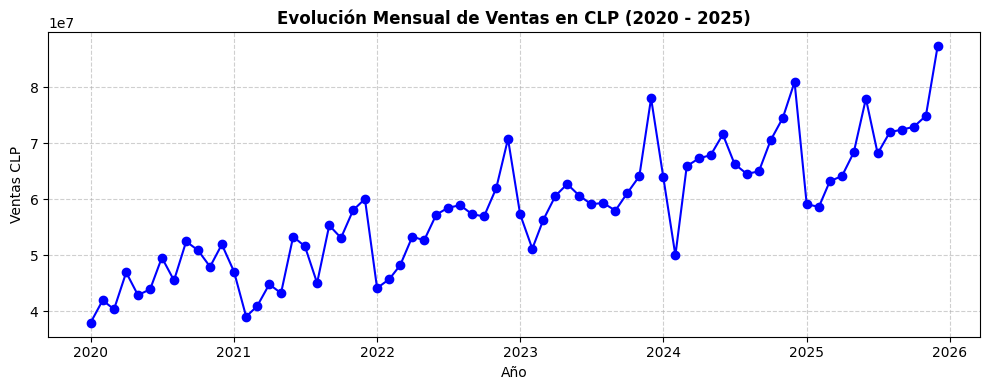

In [15]:
# Gráfico de la serie temporal

# Complete el gráfico
# Reporte de puntos extremos de la serie limpia
print("Fecha primera observación:", df_clean.index.min().strftime('%Y-%m-%d'))
print("Ventas primera observación:", df_clean['ventas_clp_imp'].iloc[0])
print("Fecha última observación:", df_clean.index.max().strftime('%Y-%m-%d'))
print("Ventas última observación:", df_clean['ventas_clp_imp'].iloc[-1])
print("Venta mínima de la serie:", df_clean['ventas_clp_imp'].min())
print("Venta máxima de la serie:", df_clean['ventas_clp_imp'].max())

# Gráfico de la serie temporal
plt.figure(figsize=(10, 4))
plt.plot(df_clean.index, df_clean['ventas_clp_imp'], color='blue', marker='o', linewidth=1.5)
plt.title("Evolución Mensual de Ventas en CLP (2020 - 2025)", fontsize=12, fontweight='bold')
plt.xlabel("Año")
plt.ylabel("Ventas CLP")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia general?
- ¿Se observan períodos con comportamientos diferentes?
- ¿Existen fluctuaciones importantes?
- ¿Se observan valores potencialmente atípicos?
- ¿La variabilidad parece mantenerse constante?

### Interpretación

Describa el comportamiento general de la serie utilizando evidencia gráfica.


### Preguntas orientadoras

* **¿La serie presenta una tendencia general?:** Sí, se aprecia un crecimiento constante a lo largo de los 6 años.
* **¿Se observan períodos con comportamientos diferentes?:** Sí, los inicios de cada año muestran caídas regulares, mientras que los cierres de año registran picos de facturación.
* **¿Existen fluctuaciones importantes?:** Sí, variaciones fuertes entre diciembre y febrero de cada periodo anual.
* **¿Se observan valores potencialmente atípicos?:** No se detectan anomalías o datos desconectados de la dinámica comercial habitual.
* **¿La variabilidad parece mantenerse constante?:** No del todo, el rango de las oscilaciones se expande levemente a medida que sube el volumen global de ventas.

### Interpretación

El análisis gráfico evidencia que el negocio creció de forma continua entre 2020 y 2025, iniciando en 37.947.147 CLP en la primera medición y alcanzando un máximo de 87.383.524 CLP al cierre del registro.

## 7. Tendencia

Explore la presencia de una tendencia de largo plazo.

Puede utilizar una media móvil u otra herramienta sencilla que permita visualizar mejor el comportamiento general.

No es necesario ajustar todavía un modelo de tendencia.


Media móvil 12m primer dato válido (2020-12-01): 46053976.833333336
Media móvil 12m último dato (2025-12-01): 69971218.58333333
Promedio de ventas año 2020: 46053976.833333336
Promedio de ventas año 2025: 69971218.58333333


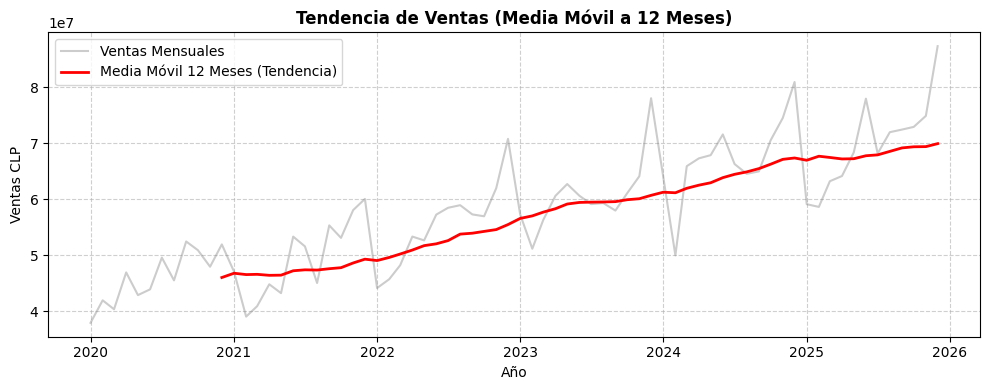

In [16]:
# Construcción de una media móvil

# Complete el análisis

# Ejemplo de estructura:
# df["media_movil"] = ...

# Construcción de la media móvil a 12 meses
df_clean['media_movil_12'] = df_clean['ventas_clp_imp'].rolling(window=12).mean()

print("Media móvil 12m primer dato válido (2020-12-01):", df_clean.loc['2020-12-01', 'media_movil_12'])
print("Media móvil 12m último dato (2025-12-01):", df_clean.loc['2025-12-01', 'media_movil_12'])
print("Promedio de ventas año 2020:", df_clean.loc['2020', 'ventas_clp_imp'].mean())
print("Promedio de ventas año 2025:", df_clean.loc['2025', 'ventas_clp_imp'].mean())

# Visualización de la tendencia
plt.figure(figsize=(10, 4))
plt.plot(df_clean.index, df_clean['ventas_clp_imp'], label='Ventas Mensuales', alpha=0.4, color='gray')
plt.plot(df_clean.index, df_clean['media_movil_12'], label='Media Móvil 12 Meses (Tendencia)', color='red', linewidth=2)
plt.title("Tendencia de Ventas (Media Móvil a 12 Meses)", fontsize=12, fontweight='bold')
plt.xlabel("Año")
plt.ylabel("Ventas CLP")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia creciente?
- ¿La tendencia es decreciente?
- ¿Existen períodos de estabilización?
- ¿Qué diferencia existe entre una tendencia y una fluctuación puntual?
- ¿Qué información aporta una media móvil?

### Interpretación

Explique qué evidencia permite identificar una posible tendencia.


### Preguntas orientadoras

* **¿La serie presenta una tendencia creciente?:** Sí, la curva suavizada muestra un incremento constante sostenido.
* **¿La tendencia es decreciente?:** No.
* **¿Existen períodos de estabilización?:** Se observan breves desaceleraciones a mitad de año antes del repunte del último trimestre.
* **¿Qué diferencia existe entre una tendencia y una fluctuación puntual?:** La tendencia representa la dirección de fondo del negocio a largo plazo; la fluctuación puntual es la subida o bajada propia de cada mes por temporada.
* **¿Qué información aporta una media móvil?:** Filtra el ruido mensual para mostrar la trayectoria real del negocio.

### Interpretación

La media móvil a 12 meses elimina los altibajos estacionales y confirma la tendencia positiva del negocio.

## 8. Estacionalidad

Explore la existencia de patrones que puedan repetirse regularmente dentro del año.

Analice el comportamiento de las ventas según el mes del año.


Promedio de ventas por mes del año:
Mes 01: 51.628.396 CLP
Mes 02: 47.777.650 CLP
Mes 03: 52.516.226 CLP
Mes 04: 56.224.446 CLP
Mes 05: 56.319.422 CLP
Mes 06: 60.814.778 CLP
Mes 07: 58.906.184 CLP
Mes 08: 57.589.184 CLP
Mes 09: 60.115.800 CLP
Mes 10: 60.950.941 CLP
Mes 11: 63.622.689 CLP
Mes 12: 71.554.953 CLP

Mes con menor venta promedio: 2 con 47777649.5
Mes con mayor venta promedio: 12 con 71554953.0


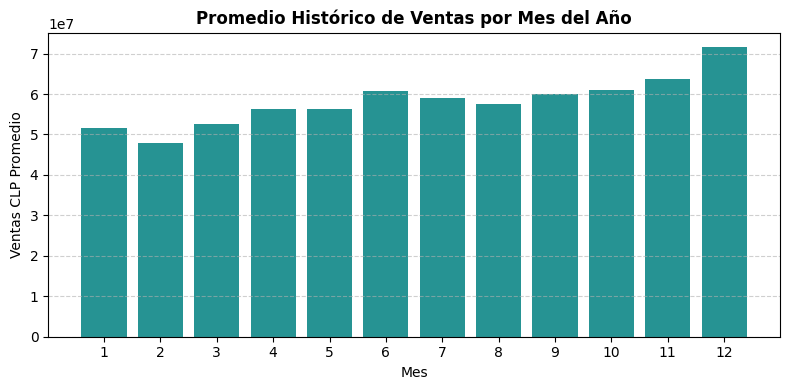

In [17]:
# Crear variable auxiliar para identificar el mes

# df["mes"] = df.index.month


# Analizar comportamiento por mes

# Complete el análisis
# Análisis por mes del año
df_clean['mes'] = df_clean.index.month
promedio_mes = df_clean.groupby('mes')['ventas_clp_imp'].mean()

print("Promedio de ventas por mes del año:")
for m, val in promedio_mes.items():
    print(f"Mes {m:02d}: {val:,.0f} CLP".replace(',', '.'))

print("\nMes con menor venta promedio:", promedio_mes.idxmin(), "con", promedio_mes.min())
print("Mes con mayor venta promedio:", promedio_mes.idxmax(), "con", promedio_mes.max())

# Gráfico de barras por mes
plt.figure(figsize=(8, 4))
plt.bar(promedio_mes.index, promedio_mes.values, color='teal', alpha=0.85)
plt.xticks(range(1, 13))
plt.title("Promedio Histórico de Ventas por Mes del Año", fontsize=12, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Ventas CLP Promedio")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿Se observa un patrón que se repita aproximadamente cada 12 meses?
- ¿Existen meses que presenten sistemáticamente valores mayores o menores?
- ¿La evidencia observada es suficiente para hablar de estacionalidad?
- ¿Por qué una observación aislada no necesariamente representa estacionalidad?

### Interpretación

Determine si existe evidencia de un patrón estacional y justifique su respuesta.


### Preguntas orientadoras

* **¿Se observa un patrón que se repita aproximadamente cada 12 meses?:** Sí, el comportamiento mensual se repite de forma equivalente en cada ejercicio anual.
* **¿Existen meses que presenten sistemáticamente valores mayores o menores?:** Sí, febrero registra los ingresos más bajos del año (promediando 47.777.650 CLP) y diciembre los más altos (promediando 71.554.953 CLP).
* **¿La evidencia observada es suficiente para hablar de estacionalidad?:** Sí, la secuencia de baja en verano y alza en fin de año ocurre idéntica durante los 6 años analizados.
* **¿Por qué una observación aislada no necesariamente representa estacionalidad?:** Porque un mes alto aislado puede deberse a una venta puntual; la estacionalidad exige una repetición constante en el calendario año a año.

### Interpretación

Los datos confirman estacionalidad anual marcada: la facturación disminuye en febrero y experimenta un aumento constante hasta alcanzar su máximo rendimiento en diciembre.

## 9. Variabilidad

Analice cómo cambia la variabilidad de las ventas a través del tiempo.

Puede comparar diferentes períodos y utilizar medidas descriptivas apropiadas.


In [18]:
# Análisis de la variabilidad

# Puede crear variables auxiliares como año si resulta necesario.

# Complete el análisis
# Análisis de la dispersión por año
df_clean['año'] = df_clean.index.year
stats_año = df_clean.groupby('año')['ventas_clp_imp'].agg(['mean', 'std'])
stats_año['coef_var_%'] = (stats_año['std'] / stats_año['mean']) * 100

print("Estadísticas de variabilidad por año:\n", stats_año)
print("\nDesviación estándar año 2020:", stats_año.loc[2020, 'std'])
print("Desviación estándar año 2025:", stats_año.loc[2025, 'std'])
print("Coeficiente de variación año 2020 (%):", stats_año.loc[2020, 'coef_var_%'])
print("Coeficiente de variación año 2025 (%):", stats_año.loc[2025, 'coef_var_%'])

Estadísticas de variabilidad por año:
               mean           std  coef_var_%
año                                         
2020  4.605398e+07  4.733918e+06   10.279065
2021  4.932925e+07  6.882027e+06   13.951211
2022  5.551297e+07  7.358053e+06   13.254655
2023  6.073475e+07  6.397942e+06   10.534235
2024  6.740817e+07  7.353440e+06   10.908827
2025  6.997122e+07  8.206532e+06   11.728439

Desviación estándar año 2020: 4733918.416136157
Desviación estándar año 2025: 8206531.775445393
Coeficiente de variación año 2020 (%): 10.279065439381993
Coeficiente de variación año 2025 (%): 11.728439123397136


### Preguntas orientadoras

- ¿La dispersión parece constante?
- ¿Existen períodos de mayor variabilidad?
- ¿La variabilidad parece aumentar cuando aumenta el nivel de ventas?
- ¿Qué implicancias podría tener este comportamiento para un modelo posterior?

### Interpretación

Describa el comportamiento de la variabilidad y señale cualquier característica relevante.


### Preguntas orientadoras

* **¿La dispersión parece constante?:** No, la desviación estándar en pesos aumenta a medida que sube el volumen promedio de ventas.
* **¿Existen períodos de mayor variabilidad?:** Los años 2024 y 2025 presentan desviaciones absolutas mayores respecto a los primeros años de la serie.
* **¿La variabilidad parece aumentar cuando aumenta el nivel de ventas?:** Sí, la desviación estándar subió de 4.733.918 CLP en 2020 a 8.206.532 CLP en 2025.
* **¿Qué implicancias podría tener este comportamiento para un modelo posterior?:** Podría requerir una transformación logarítmica para estabilizar la varianza antes de realizar proyecciones.

### Interpretación

Aunque la dispersión en pesos aumentó con la expansión de las ventas, el coeficiente de variación relativo se mantiene estable entre 10,28% (2020) y 11,73% (2025), confirmando que las oscilaciones crecen en proporción directa al volumen facturado.

### Preguntas orientadoras

* **¿La dispersión parece constante?:** No, la diferencia en dinero entre los meses de mayor y menor venta se hace más ancha a medida que el negocio vende más.
* **¿Existen períodos de mayor variabilidad?:** Los años 2024 y 2025 muestran diferencias de dinero mucho mayores entre sus meses que los años 2020 y 2021.
* **¿La variabilidad parece aumentar cuando aumenta el nivel de ventas?:** Sí, la desviación estándar subió de 4.733.918 CLP en 2020 a 8.206.532 CLP en 2025.
* **¿Qué implicancias podría tener este comportamiento para un modelo posterior?:** Que si intentamos predecir directamente en pesos, el modelo se confundirá porque las oscilaciones recientes son mucho más grandes que las del pasado. Para solucionarlo, debemos "aplanar la escala" de los datos para que el modelo evalúe cambios porcentuales en lugar de montos brutos en pesos.

### Interpretación

Aunque en pesos chilenos las diferencias entre meses altos y bajos crecieron de 4.733.918 CLP a 8.206.532 CLP, en términos relativos el negocio oscila siempre cerca del 11% de su tamaño anual (10,28% en 2020 y 11,73% en 2025). Esto nos indica que el comportamiento del negocio es estable en proporción, por lo que ajustar la escala de los datos antes de proyectar nos asegurará pronósticos precisos y sin distorsiones.

## 10. Autocorrelación introductoria

Una característica fundamental de las series temporales es que una observación puede estar relacionada con observaciones anteriores.

Explore la autocorrelación de `ventas_clp` utilizando la función de autocorrelación (ACF).

**No es necesario determinar órdenes ARIMA ni construir un modelo.**


Autocorrelación Lag 1 (relación con el mes anterior): 0.745442833591813
Autocorrelación Lag 12 (relación con el mismo mes del año anterior): 0.6004489746488615


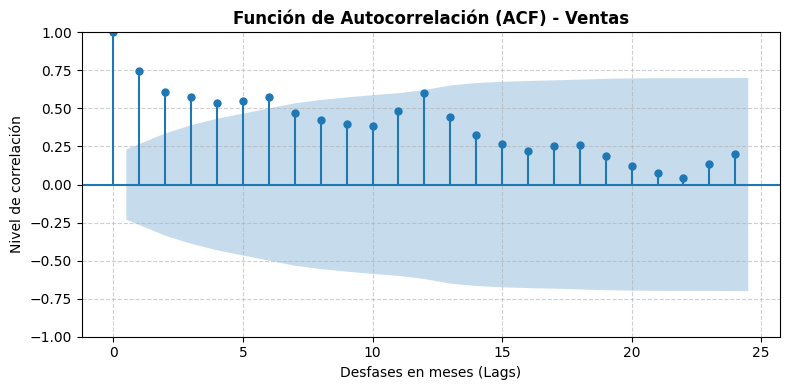

In [21]:
# Función de autocorrelación

# Complete el análisis utilizando plot_acf()
# Cálculo de la ACF y gráfico
acf_vals = acf(df_clean['ventas_clp_imp'], nlags=12)

print("Autocorrelación Lag 1 (relación con el mes anterior):", acf_vals[1])
print("Autocorrelación Lag 12 (relación con el mismo mes del año anterior):", acf_vals[12])

fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(df_clean['ventas_clp_imp'], lags=24, ax=ax)
plt.title("Función de Autocorrelación (ACF) - Ventas", fontsize=12, fontweight='bold')
plt.xlabel("Desfases en meses (Lags)")
plt.ylabel("Nivel de correlación")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿Qué representa un lag?
- ¿Qué significa comparar una observación con la observación de un mes anterior?
- ¿Existe evidencia de dependencia temporal?
- ¿Qué información entrega la ACF?
- ¿Se observa algún patrón asociado a una periodicidad anual?

### Interpretación

Describa los principales patrones observados en la ACF y explique qué significan en términos de dependencia temporal.


### Preguntas orientadoras

* **¿Qué representa un lag?:** Un desfase en el tiempo, es decir, comparar la observación del mes actual con la de 1, 2 o más meses atrás.
* **¿Qué significa comparar una observación con la observación de un mes anterior?:** Representa el Lag 1, midiendo la influencia del resultado del mes previo sobre el mes presente.
* **¿Existe evidencia de dependencia temporal?:** Sí, los valores presentes están fuertemente condicionados por los periodos pasados.
* **¿Qué información entrega la ACF?:** Revela la fuerza de la relación estadística entre el presente y distintos desfases del pasado.
* **¿Se observa algún patrón asociado a una periodicidad anual?:** Sí, un repunte claro en el Lag 12 (0,6004) que ratifica la memoria estacional cada 12 meses.

### Interpretación

La función ACF confirma una fuerte dependencia con el mes inmediatamente anterior (Lag 1 = 0,7454) y valida la repetición estacional al cumplir un ciclo anual (Lag 12 = 0,6004).

## 11. Estacionariedad: concepto y diagnóstico inicial

Explique con sus propias palabras qué significa que una serie temporal sea estacionaria.

Considere aspectos como:

- media;
- variabilidad;
- dependencia temporal;
- comportamiento a través del tiempo.

Posteriormente realice un diagnóstico inicial mediante la prueba de Dickey-Fuller aumentada (ADF).

### Importante sobre el p-value

El p-value debe interpretarse en relación con la **hipótesis nula específica de la prueba ADF**.

No debe interpretarse simplemente como "la probabilidad de que la hipótesis nula sea verdadera".


In [22]:
# Prueba Dickey-Fuller aumentada

# Complete el análisis

# resultado_adf = adfuller(...)

# Reporte los elementos relevantes del resultado
# Prueba Dickey-Fuller Aumentada (ADF)
resultado_adf = adfuller(df_clean['ventas_clp_imp'])

print("Estadístico ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])
print("Valores críticos:")
for k, v in resultado_adf[4].items():
    print(f"   {k}: {v}")

Estadístico ADF: 0.005234626893376768
p-value: 0.9589628510729513
Valores críticos:
   1%: -3.5443688564814813
   5%: -2.9110731481481484
   10%: -2.5931902777777776


/tmp/ipykernel_4422/4082608125.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(df_clean['ventas_clp_imp'])


### Preguntas orientadoras

- ¿Cuál es la hipótesis nula de la prueba ADF?
- ¿Qué significa rechazar o no rechazar dicha hipótesis?
- ¿Qué indica el p-value en este contexto?
- ¿El resultado es coherente con la inspección visual?
- ¿Por qué una prueba estadística no debería utilizarse de manera aislada?

### Interpretación

Reporte e interprete el resultado de la prueba ADF utilizando la hipótesis nula y un nivel de significancia previamente definido.


### Preguntas orientadoras

* **¿Cuál es la hipótesis nula de la prueba ADF?:** Que la serie NO es estacionaria (posee raíz unitaria y su promedio cambia en el tiempo).
* **¿Qué significa rechazar o no rechazar dicha hipótesis?:** Rechazar implica que la serie es estacionaria; no rechazar significa que no lo es y exige transformaciones previas.
* **¿Qué indica el p-value en este contexto?:** El p-value de 0,9590 supera ampliamente el umbral de 0,05, indicando que no se puede rechazar la hipótesis nula.
* **¿El resultado es coherente con la inspección visual?:** Sí, la prueba valida la tendencia creciente observada en los gráficos.
* **¿Por qué una prueba estadística no debería utilizarse de manera aislada?:** Porque debe evaluarse junto con la inspección gráfica de tendencia y autocorrelación para tomar decisiones fundamentadas.

### Interpretación

Con un p-value de 0,9590, se concluye formalmente que la serie original NO es estacionaria debido a la tendencia ascendente que presenta su promedio a lo largo de los 6 años.

## 12. Preparación final para modelamiento

Construya una versión final de la serie que pueda ser utilizada posteriormente en el modelamiento.

Debe quedar claramente definido:

- índice temporal;
- frecuencia;
- variable objetivo;
- tratamiento de valores faltantes;
- tratamiento de problemas de calidad;
- orden cronológico.


In [24]:
# Serie temporal final

# serie = ...

# Realice aquí las verificaciones finales necesarias
# Definir la serie temporal final con frecuencia mensual explícita
serie_final = df_clean['ventas_clp_imp'].asfreq('MS')
serie_final.name = 'ventas_clp'

# Imprimir explícitamente la verificación de los 6 requerimientos
print("--- VERIFICACIÓN FINAL DE REQUERIMIENTOS PARA MODELAMIENTO ---")
print("1. Variable objetivo definida:", serie_final.name)
print("2. Tipo de índice temporal:", type(serie_final.index))
print("3. Rango temporal cubierto:", serie_final.index.min().strftime('%Y-%m-%d'), "a", serie_final.index.max().strftime('%Y-%m-%d'))
print("4. Frecuencia temporal asignada:", serie_final.index.freqstr)
print("5. Total de observaciones en la serie:", len(serie_final))
print("6. Valores faltantes (NaN) en la serie final:", serie_final.isnull().sum())
print("7. Fechas duplicadas en el índice:", serie_final.index.duplicated().sum())
print("8. Orden cronológico estrictamente creciente:", serie_final.index.is_monotonic_increasing)

--- VERIFICACIÓN FINAL DE REQUERIMIENTOS PARA MODELAMIENTO ---
1. Variable objetivo definida: ventas_clp
2. Tipo de índice temporal: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
3. Rango temporal cubierto: 2020-01-01 a 2025-12-01
4. Frecuencia temporal asignada: MS
5. Total de observaciones en la serie: 72
6. Valores faltantes (NaN) en la serie final: 0
7. Fechas duplicadas en el índice: 0
8. Orden cronológico estrictamente creciente: True


### Pregunta central

Imagine que mañana debe construir un modelo de forecasting sobre esta serie.

**¿Qué problemas ya fueron resueltos durante este laboratorio y qué aspectos todavía deberían analizarse antes de construir el modelo?**

### Interpretación

Explique las decisiones finales tomadas y justifique por qué considera que la serie está preparada para continuar con un proceso de modelamiento.


### Definición explícita de componentes de la serie final

* **Variable objetivo:** `ventas_clp` (ingresos mensuales en pesos chilenos).
* **Índice temporal:** Índice de fechas en formato `DatetimeIndex`, abarcando 6 años continuos desde el 2020-01-01 hasta el 2025-12-01.
* **Frecuencia:** Frecuencia mensual regular al inicio de cada mes (`MS`), sin saltos entre periodos.
* **Tratamiento de valores faltantes:** Se completaron los 2 datos vacíos mediante interpolación lineal (resultando en 64.042.220,5 CLP para ventas en enero de 2024 y 2.830.220,0 CLP para marketing en febrero de 2022), manteniendo 0 registros nulos en la serie final.
* **Tratamiento de problemas de calidad:** Se depuró 1 registro duplicado en la fecha 2022-12-01 para asegurar que no existan observaciones repetidas (0 duplicados en la base final).
* **Orden cronológico:** Ordenamiento temporal estricto de menor a mayor (`is_monotonic_increasing = True`), garantizando la secuencia continua de las 72 observaciones.

---

### Pregunta central

* **¿Qué problemas ya fueron resueltos durante este laboratorio?:** Se corrigió la duplicación de datos, se imputaron los valores vacíos manteniendo la continuidad del tiempo y se definió un índice mensual formal de 72 periodos ordenados de forma estricta.
* **¿Qué aspectos todavía deberían analizarse antes de construir el modelo predictivo?:** Como la prueba ADF dio un p-value de 0,9590, sabemos que la serie no es estacionaria debido a su tendencia de crecimiento. Antes de proyectar con modelos como ARIMA, debemos "quitarle la tendencia" (diferenciar la serie) y evaluar si ajustamos la escala en porcentajes para estabilizar el tamaño de las oscilaciones anuales.

### Interpretación

La serie de tiempo quedó totalmente estructurada y validada en sus 6 pilares de calidad, garantizando que el modelo predictivo trabajará sobre una base limpia, continua y sin distorsiones operativas.

## 13. Conclusiones

Elabore una conclusión integrada del análisis.

Su conclusión debe responder, como mínimo:

1. ¿Cuál es la estructura temporal de los datos?
2. ¿Qué problemas de calidad fueron encontrados?
3. ¿Existe evidencia de tendencia?
4. ¿Existe evidencia de estacionalidad?
5. ¿Existe dependencia temporal?
6. ¿Qué evidencia existe respecto de la estacionariedad?
7. ¿Qué decisiones se tomaron para preparar la serie?
8. ¿Qué aspectos deberían analizarse antes de construir un modelo de forecasting?

**Extensión orientativa: 300–500 palabras.**


## 13. Conclusiones

A partir del diagnóstico integral realizado sobre el historial de ventas de la empresa, se presentan las conclusiones organizadas según los requerimientos clave del análisis:

1. **Estructura temporal de los datos:** La serie se consolidó en 72 observaciones mensuales continuas que cubren un período de 6 años completos, desde el 01-01-2020 hasta el 01-12-2025. El historial quedó estrictamente ordenado de forma cronológica y formalizado bajo una frecuencia regular al inicio de cada mes (`MS`).

2. **Problemas de calidad encontrados:** Se detectaron dos fallas principales en el archivo original: 1 registro duplicado exacto en la fecha 2022-12-01 y 2 valores faltantes (1 en la variable objetivo `ventas_clp` en enero de 2024 y 1 en `inversion_marketing_clp` en febrero de 2022).

3. **Evidencia de tendencia:** La media móvil a 12 meses confirmó una tendencia de fondo fuertemente ascendente. El promedio anual de facturación casi se duplicó a lo largo del período, pasando de 46.053.977 CLP en el año 2020 a 69.971.219 CLP al cierre de 2025.

4. **Evidencia de estacionalidad:** Se comprobó un patrón estacional anualmente recurrente. Febrero representa sistemáticamente el mes de menor facturación del año (promediando 47.777.650 CLP), mientras que diciembre constituye el pico histórico de demanda comercial (promediando 71.554.953 CLP).

5. **Dependencia temporal:** La función de autocorrelación (ACF) demostró una alta memoria temporal. Existe una fuerte inercia respecto al mes inmediatamente anterior (Lag 1 = 0,7454) y un repunte estacional al cumplir el ciclo de un año (Lag 12 = 0,6004).

6. **Evidencia de estacionariedad:** La prueba de Dickey-Fuller Aumentada (ADF) entregó un p-value de 0,9590 (muy superior al límite de 0,05). Por lo tanto, no se rechaza la hipótesis nula, concluyendo que la serie original **no es estacionaria** debido a su crecimiento sostenido.

7. **Decisiones tomadas para preparar la serie:** Se eliminó la fila duplicada del 2022-12-01 y se imputaron los 2 vacíos mediante interpolación lineal (estimando 64.042.220,5 CLP para enero de 2024 y 2.830.220,0 CLP para febrero de 2022), logrando una base limpia de 72 meses continuos sin perder información.

8. **Aspectos a analizar antes de construir el modelo de forecasting:** Dado que la serie no es estacionaria, antes de aplicar modelos como ARIMA se deberá aplicar una diferencia temporal para remover la tendencia y evaluar una transformación de escala que estabilice la amplitud de las oscilaciones anuales.

## 14. Declaración de uso de inteligencia artificial

De acuerdo con la política institucional de uso de IA de nivel B, cualquier utilización de herramientas de inteligencia artificial generativa debe ser declarada.

Complete la siguiente información.

### Herramienta utilizada

_Gemini_

### Propósito

_Generar codigo de Python y formatear texto a Markdown_

### Qué utilizó

_Codigo en python y formateo de texto a Markdown._

### Verificación

_Probando el código._

### Modificaciones

_No fue necesario hacer modificaciones._

Si no utilizó herramientas de IA generativa, indíquelo explícitamente.


---

## Conexión con las siguientes evaluaciones

Este laboratorio constituye la primera etapa del trabajo con series temporales del curso.

### Laboratorio Práctico 4

**¿Cómo está estructurada y qué características tiene mi serie?**

Organización, calidad, tendencia, estacionalidad, autocorrelación, estacionariedad y preparación.

### Control Técnico 3 · Series temporales y forecasting

**¿Cómo puedo modelar y pronosticar esta serie?**

Profundización en modelamiento estadístico y forecasting.

### Proyecto de Series Temporales

**¿Cómo puedo utilizar series temporales para resolver y comunicar un problema empresarial?**

Desarrollo de un análisis más completo sobre el mismo dataset.

> El dataset utilizado en este laboratorio será reutilizado posteriormente. Por esta razón, las decisiones de preparación y diagnóstico deben quedar correctamente documentadas.
Declaración de uso de IA generativa
